# Lazy MLP Evaluation

This notebook evaluates the Stage 2 Improved MLP using the saved best checkpoint and computes threshold-based metrics on the dev set.

In [5]:
from pathlib import Path

# Detect project root dynamically
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "README.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: /Users/hongjingren/Documents/6140/Noise-Robust-Voice-Activity-Detection-FINAL


In [6]:
# Define paths relative to PROJECT_ROOT
output_dir = PROJECT_ROOT / "outputs" / "stage2_lazy_mlp_q25_e3"
generated_dir = PROJECT_ROOT / "data" / "generated"
norm_stats_path = PROJECT_ROOT / "data" / "generated" / "train" / "features" / "noisy_norm_stats.npz"

best_model_path = output_dir / "best_model.pt"
args_path = output_dir / "train_args.json"
history_path = output_dir / "training_history.json"

print(f"output_dir: {output_dir}")
print(f"generated_dir: {generated_dir}")
print(f"norm_stats_path: {norm_stats_path}")
print(f"best_model.pt exists: {best_model_path.exists()}")
print(f"train_args.json exists: {args_path.exists()}")
print(f"training_history.json exists: {history_path.exists()}")

output_dir: /Users/hongjingren/Documents/6140/Noise-Robust-Voice-Activity-Detection-FINAL/outputs/stage2_lazy_mlp_q25_e3
generated_dir: /Users/hongjingren/Documents/6140/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated
norm_stats_path: /Users/hongjingren/Documents/6140/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated/train/features/noisy_norm_stats.npz
best_model.pt exists: True
train_args.json exists: True
training_history.json exists: True


In [7]:
# Import required modules for evaluation
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from torch.utils.data import DataLoader

# Robust imports for project modules
import sys

project_src = PROJECT_ROOT / "src"
baseline_path = project_src / "05_baseline_training"
lazy_path = project_src / "07_stage2_lazy_pipeline"
for path in (baseline_path, lazy_path):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

try:
    from baseline_mlp import BaselineMLP
except ImportError:
    raise

try:
    from lazy_frame_dataset import VADLazyFrameDataset
except ImportError:
    raise

In [8]:
# Load training args and print a short summary
with open(args_path) as f:
    args = json.load(f)

print("Loaded training arguments:")
print(f"  manifest_type: {args['manifest_type']}")
print(f"  subset fractions: train={args.get('train_subset_fraction', 'N/A')}, dev={args.get('dev_subset_fraction', 'N/A')}")
print(f"  dropout: {args['dropout']}")
print(f"  epochs: {args['epochs']}")
print(f"  batch_size: {args['batch_size']}")
print(f"  lr: {args['lr']}")
print(f"  evaluation dev split uses subset_fraction=0.25 and subset_seed={args['seed'] + 1}")

Loaded training arguments:
  manifest_type: noisy
  subset fractions: train=0.25, dev=0.25
  dropout: 0.1
  epochs: 3
  batch_size: 512
  lr: 0.001
  evaluation dev split uses subset_fraction=0.25 and subset_seed=43


In [9]:
# Rebuild dev dataset and dataloader with the same lazy settings
dev_dataset = VADLazyFrameDataset(
    generated_dir=generated_dir,
    split="dev",
    manifest_type="noisy",
    norm_stats_path=norm_stats_path,
    subset_fraction=0.25,
    subset_seed=args["seed"] + 1,
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False,
)

print(f"Dev dataset size: {len(dev_dataset)}")
print(f"Dev dataloader batches: {len(dev_loader)}")

Loaded 500 examples from dev noisy manifest
Applied subset sampling: 125/500 examples (25.00%)
Frame dataset: 270379 total frames from 125 sequences
Dev dataset size: 270379
Dev dataloader batches: 529


In [10]:
# Rebuild the model and load the checkpoint
model = BaselineMLP(
    input_dim=1331,
    hidden_dims=(512, 256),
    dropout=args["dropout"],
)

# Device selection for inference
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device)
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint)
model.eval()

print(f"Using device: {device}")

Using device: mps


In [11]:
# Run inference on dev loader and collect logits, probabilities, and labels
all_logits = []
all_probs = []
all_labels = []

with torch.no_grad():
    for batch in dev_loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        logits = model(x).squeeze(-1)
        probs = torch.sigmoid(logits)
        all_logits.append(logits.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y.cpu().numpy())

all_logits = np.concatenate(all_logits, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"Collected logits shape: {all_logits.shape}")
print(f"Collected probabilities shape: {all_probs.shape}")
print(f"Collected labels shape: {all_labels.shape}")

/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Collected logits shape: (270379,)
Collected probabilities shape: (270379,)
Collected labels shape: (270379,)


In [12]:
# Helper functions for metrics

def confusion_counts(labels, preds):
    tp = int(((labels == 1) & (preds == 1)).sum())
    fp = int(((labels == 0) & (preds == 1)).sum())
    fn = int(((labels == 1) & (preds == 0)).sum())
    tn = int(((labels == 0) & (preds == 0)).sum())
    return tp, fp, fn, tn


def precision(tp, fp):
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def recall(tp, fn):
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


def f1_score(p, r):
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0


def far(tp, fp):
    return fp / (tp + fp) if (tp + fp) > 0 else 0.0


def miss_rate(fn, tp):
    return fn / (tp + fn) if (tp + fn) > 0 else 0.0

# Note: FAR is defined here as FP / (TP + FP), following the standard project convention when no alternate definition is available.

In [13]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

for threshold in thresholds:
    preds = (all_probs >= threshold).astype(np.int64)
    tp, fp, fn, tn = confusion_counts(all_labels, preds)
    p = precision(tp, fp)
    r = recall(tp, fn)
    f1 = f1_score(p, r)
    current_far = far(tp, fp)
    current_miss_rate = miss_rate(fn, tp)
    results.append({
        "threshold": threshold,
        "F1": f1,
        "FAR": current_far,
        "miss_rate": current_miss_rate,
        "precision": p,
        "recall": r,
    })

results_df = pd.DataFrame(results)

In [14]:
# Display the threshold sweep table
results_df

,threshold,F1,FAR,miss_rate,precision,recall
0,0.3,0.859888,0.224986,0.034363,0.775014,0.965637
1,0.4,0.866655,0.189338,0.069043,0.810662,0.930957
2,0.5,0.866760,0.145103,0.121042,0.854897,0.878958
3,0.6,0.857582,0.109463,0.173020,0.890537,0.826980
4,0.7,0.839892,0.081665,0.226204,0.918335,0.773796


In [15]:
# Identify and print best threshold by dev F1
best_index = int(results_df["F1"].idxmax())
best_row = results_df.iloc[best_index]

print(f"Best threshold by dev F1: {best_row['threshold']}")
print(f"Best dev F1: {best_row['F1']:.4f}")
print(f"FAR at best threshold: {best_row['FAR']:.4f}")
print(f"Miss Rate at best threshold: {best_row['miss_rate']:.4f}")

Best threshold by dev F1: 0.5
Best dev F1: 0.8668
FAR at best threshold: 0.1451
Miss Rate at best threshold: 0.1210


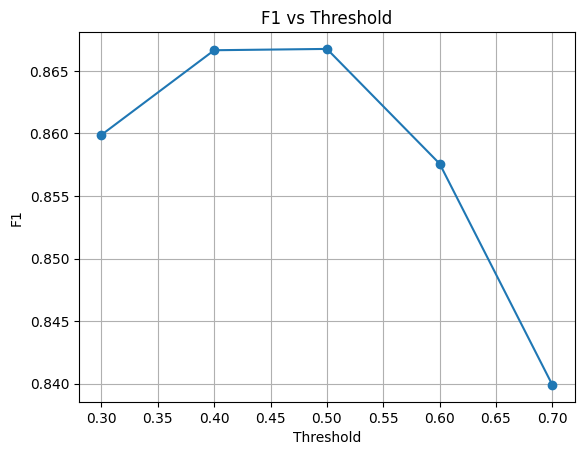

In [16]:
# Plot F1 vs threshold
plt.plot(results_df["threshold"], results_df["F1"], marker="o")
plt.title("F1 vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.grid(True)
plt.show()

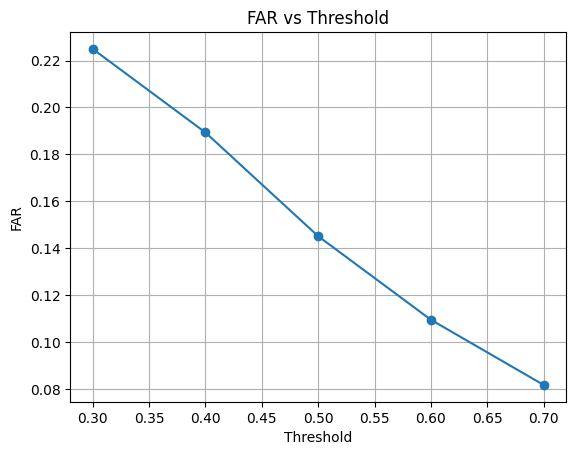

In [17]:
# Plot FAR vs threshold
plt.plot(results_df["threshold"], results_df["FAR"], marker="o")
plt.title("FAR vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("FAR")
plt.grid(True)
plt.show()

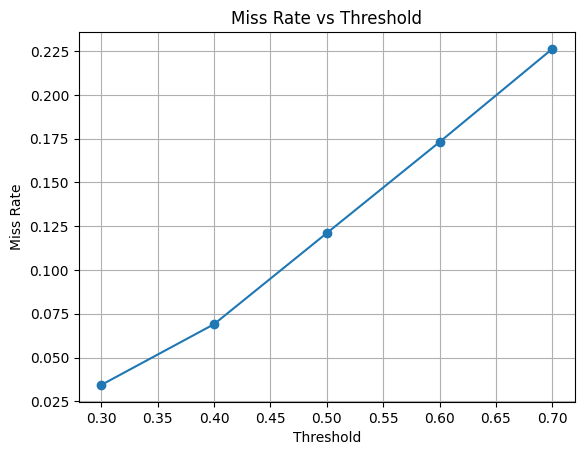

In [18]:
# Plot Miss Rate vs threshold
plt.plot(results_df["threshold"], results_df["miss_rate"], marker="o")
plt.title("Miss Rate vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Miss Rate")
plt.grid(True)
plt.show()

## Evaluation Interpretation

The lazy MLP is now evaluated on the dev set using the saved best checkpoint and a threshold sweep. Threshold selection affects the trade-off between false alarms and missed speech. The best threshold is chosen by dev F1 in this notebook, which completes the evaluation stage for Step 2 Improved MLP.

In this stage, we replaced the offline feature extraction pipeline with a lazy on-the-fly feature computation using a PyTorch Dataset.
The same MLP architecture was used to isolate the effect of the pipeline change.

The training results show stable convergence, with both training loss decreasing and dev accuracy improving across epochs.
The best dev accuracy reaches approximately **0.8143**, which is comparable to the baseline model.

In evaluation, we perform threshold sweeping and obtain the best dev F1 score of **0.8668 at threshold 0.5**.
The trade-off between false alarm rate (FAR) and miss rate behaves as expected: increasing the threshold reduces FAR but increases miss rate.

Overall, these results demonstrate that the lazy feature extraction pipeline does not degrade model performance and is compatible with the baseline MLP architecture, while enabling more flexible modeling for sequence-based methods in later stages.